# 95 — Interactive matching of nodal detections to Geode/streamer metadata

This notebook is a **review and matching workspace**. It does not rerun detections. It uses the SQLite catalog created by the metadata indexing notebook and the nodal `90_*` notebook.

Goal:

1. Load anonymous or weakly-matched nodal detections.
2. Load candidate Geode/streamer metadata shots using broad time windows and possible clock offsets.
3. Estimate approximate source position from the nodal gather itself.
4. Score candidate metadata matches using time, line, source position, and source type.
5. Save candidate and reviewed matches back to SQLite.

Important assumptions handled here:

- The EPIC/Jochen Geode laptop on day 3 was observed to be **11.5 s ahead of UTC** at the start of T1 1-m refraction.
- Other Geode systems may have different clock offsets, and day 1/2 GeoView systems might even have local-time files.
- A Geode file time may represent the **first trigger** in a multi-shot stack, so matching should allow a stack window after the file time.
- Nodal detections may align better with the true hammer/PEG impact time than the Geode stack file time.


In [19]:
from pathlib import Path
import json
import sqlite3
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from obspy import read, UTCDateTime
from scipy.signal import hilbert

# Optional local modules
import sys
LIB = Path('../lib').resolve()
if LIB.exists() and str(LIB) not in sys.path:
    sys.path.append(str(LIB))

try:
    from segy_tools.gather import plot_wiggle_gather_from_stream
    HAVE_SEGY_TOOLS = True
except Exception as e:
    HAVE_SEGY_TOOLS = False
    print('segy_tools not available:', e)


segy_tools not available: No module named 'segy_tools'


## 1. Configuration

Adjust paths and tolerance values here. Start with broad tolerances; we can tighten them after reviewing actual matches.


In [20]:
PROJECT_ROOT = Path('/Volumes/tachyon/LBSSP_DATA')
CATALOG_DB = PROJECT_ROOT / 'catalog' / 'lbssp_shot_catalog.sqlite'
OUTPUT_DIR = PROJECT_ROOT / 'catalog' / 'match_review'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Broad default time window for candidate matching.
# This is intentionally generous because Geode file times may be first trigger in a stack.
DEFAULT_TIME_BEFORE_S = 30.0
DEFAULT_TIME_AFTER_S = 180.0

# If a file represents first shot in stack, allow after-time based on number of blows too.
SECONDS_PER_BLOW_GUESS = 6.0
MIN_STACK_AFTER_S = 60.0
MAX_STACK_AFTER_S = 180.0

# Known or suspected clock offsets by survey name.
# Definition: corrected_utc = recorded_time + offset_seconds.
# If laptop clock was 11.5 s ahead of UTC, recorded_time is late, so offset is -11.5 s.
GEODE_TIME_OFFSETS_S = {
    'T1_1m_Refraction': -11.5,
    # Unknown offsets: leave as 0 for now; use exploratory offset search below if needed.
    'T1_2m_Refraction': -11.5,
    'T1_Streamer_MASW': 0.0,
    'T1A_Streamer_MASW': 0.0,
    'T3_1m_Refraction': -11.5,
    'T4_1m_Refraction': -11.5,
}

# Optional offset hypotheses for exploration. Useful when day 1/2 clock is unknown.
# These are applied in addition to the survey's base offset when generating candidates.
#OFFSET_HYPOTHESES_S = [0.0, -11.5, 11.5, -60.0, 60.0, -3600.0*4, 3600.0*4]
OFFSET_HYPOTHESES_S = [0.0, -60.0, 60.0]


# Scoring weights. Larger score is better.
TIME_SCALE_S = 60.0
SOURCE_X_SCALE_M = 10.0

# Source-position estimation windows relative to gather start.
# Nodal shot gathers generally start shortly before detection/onset.
ENERGY_TMIN_S = 0.00
ENERGY_TMAX_S = 0.25
EARLY_TMIN_S = 0.00
EARLY_TMAX_S = 0.10

# Review subset. Set to None for all unmatched nodal events.
MAX_EVENTS_TO_REVIEW = 50


## 2. Database helpers

In [21]:
def connect_catalog(db_path=CATALOG_DB):
    db_path = Path(db_path)
    if not db_path.exists():
        raise FileNotFoundError(db_path)
    conn = sqlite3.connect(db_path)
    conn.execute('PRAGMA foreign_keys = ON;')
    conn.execute('PRAGMA busy_timeout = 30000;')
    return conn


def table_exists(conn, table):
    row = conn.execute(
        "SELECT name FROM sqlite_master WHERE type='table' AND name=?", (table,)
    ).fetchone()
    return row is not None


def load_table(conn, table):
    if not table_exists(conn, table):
        print(f'Table not found: {table}')
        return pd.DataFrame()
    return pd.read_sql(f'SELECT * FROM {table}', conn)


def ensure_match_tables(conn):
    conn.execute('''
        CREATE TABLE IF NOT EXISTS nodal_geode_match_candidates (
            candidate_id TEXT PRIMARY KEY,
            run_time_utc TEXT,
            nodal_event_id TEXT,
            geode_event_id TEXT,
            line TEXT,
            nodal_time_utc TEXT,
            geode_time_utc TEXT,
            corrected_geode_time_utc TEXT,
            time_residual_s REAL,
            offset_hypothesis_s REAL,
            geode_survey TEXT,
            geode_file_no TEXT,
            geode_source_x_m REAL,
            nodal_estimated_source_x_m REAL,
            source_x_residual_m REAL,
            source_type TEXT,
            operator TEXT,
            plate_type TEXT,
            n_blows REAL,
            score REAL,
            match_reason TEXT,
            needs_review INTEGER
        )
    ''')
    conn.execute('''
        CREATE TABLE IF NOT EXISTS nodal_geode_matches_reviewed (
            nodal_event_id TEXT PRIMARY KEY,
            geode_event_id TEXT,
            accepted INTEGER,
            review_status TEXT,
            review_time_utc TEXT,
            reviewer TEXT,
            notes TEXT,
            source_x_m REAL,
            source_type TEXT,
            operator TEXT,
            plate_type TEXT,
            n_blows REAL,
            geode_file_no TEXT,
            time_residual_s REAL,
            nodal_estimated_source_x_m REAL,
            source_x_residual_m REAL
        )
    ''')
    conn.commit()

conn = connect_catalog()
ensure_match_tables(conn)


## 3. Load catalog tables

In [22]:
shot_events = load_table(conn, 'shot_events')
gather_files = load_table(conn, 'shot_gather_files')
trace_index = load_table(conn, 'trace_index')
picks = load_table(conn, 'picks')
receiver_geometry = load_table(conn, 'receiver_geometry')

print('shot_events:', len(shot_events))
print('shot_gather_files:', len(gather_files))
print('trace_index:', len(trace_index))
print('picks:', len(picks))
print('receiver_geometry:', len(receiver_geometry))

display(shot_events.head())


shot_events: 3752
shot_gather_files: 3610
trace_index: 344514
picks: 787402
receiver_geometry: 7530


,event_id,instrument_system,line,transect,survey,survey_type,shot_no,file_no,source_x_m,source_type,...,metadata_match_time_error_s,detection_n_seed_ids,detection_n_stations,detection_seed_ids,detection_stations,snr_rms,n_receivers_extracted,n_traces_extracted,status,notes
0,GEODE_T1_1M_REFRACTION_F3001,geode,T1,T1,T1_1m_refraction,refraction,1.0,3001.0,82.5,hammer,...,NaN,NaN,None,None,None,NaN,NaN,NaN,None,None
1,GEODE_T1_1M_REFRACTION_F3002,geode,T1,T1,T1_1m_refraction,refraction,2.0,3002.0,82.5,hammer,...,NaN,NaN,None,None,None,NaN,NaN,NaN,None,None
2,GEODE_T1_1M_REFRACTION_F3003,geode,T1,T1,T1_1m_refraction,refraction,3.0,3003.0,82.5,hammer,...,NaN,NaN,None,None,None,NaN,NaN,NaN,None,None
3,GEODE_T1_1M_REFRACTION_F3004,geode,T1,T1,T1_1m_refraction,refraction,4.0,3004.0,82.5,hammer,...,NaN,NaN,None,None,None,NaN,NaN,NaN,None,None
4,GEODE_T1_1M_REFRACTION_F3005,geode,T1,T1,T1_1m_refraction,refraction,5.0,3005.0,82.5,hammer,...,NaN,NaN,None,None,None,NaN,NaN,NaN,None,None


In [23]:
def normalize_columns(df):
    # Make expected columns exist even if older notebooks used slightly different schema.
    defaults = {
        'event_id': None,
        'instrument_system': None,
        'line': None,
        'timewindow_label': None,
        'shot_time_utc': None,
        'detection_time_utc': None,
        'source_x_m': np.nan,
        'source_type': None,
        'operator': None,
        'plate_type': None,
        'n_blows': np.nan,
        'file_no': None,
        'survey': None,
        'survey_type': None,
        'metadata_match_status': None,
    }
    out = df.copy()
    for c, v in defaults.items():
        if c not in out.columns:
            out[c] = v
    return out

shot_events = normalize_columns(shot_events)

# Candidate groups
nodal_events = shot_events[shot_events['instrument_system'].fillna('').str.contains('nodal', case=False, na=False)].copy()
geode_events = shot_events[~shot_events['instrument_system'].fillna('').str.contains('nodal', case=False, na=False)].copy()

print('nodal_events:', len(nodal_events))
print('geode/non-nodal metadata events:', len(geode_events))

display(nodal_events[['event_id','line','timewindow_label','shot_time_utc','detection_time_utc','source_x_m','source_type','metadata_match_status']].head())
display(geode_events[['event_id','line','survey','shot_time_utc','source_x_m','source_type','operator','plate_type','n_blows','file_no']].head())


nodal_events: 3425
geode/non-nodal metadata events: 327


,event_id,line,timewindow_label,shot_time_utc,detection_time_utc,source_x_m,source_type,metadata_match_status
327,T1_N1_Streamer_T1_N1_E00001,T1,T1_N1_Streamer,None,2026-05-16T17:13:01.890000Z,NaN,None,unmatched_nearest_183052.110s_exceeds_tolerance
328,T1_N1_Streamer_T1_N1_E00002,T1,T1_N1_Streamer,None,2026-05-16T17:13:14.824000Z,NaN,None,unmatched_nearest_183039.176s_exceeds_tolerance
329,T1_N1_Streamer_T1_N1_E00003,T1,T1_N1_Streamer,None,2026-05-16T17:13:28.030000Z,NaN,None,unmatched_nearest_183025.970s_exceeds_tolerance
330,T1_N1_Streamer_T1_N1_E00004,T1,T1_N1_Streamer,None,2026-05-16T17:13:30.858000Z,NaN,None,unmatched_nearest_183023.142s_exceeds_tolerance
331,T1_N1_Streamer_T1_N1_E00005,T1,T1_N1_Streamer,None,2026-05-16T17:13:33.392000Z,NaN,None,unmatched_nearest_183020.608s_exceeds_tolerance


,event_id,line,survey,shot_time_utc,source_x_m,source_type,operator,plate_type,n_blows,file_no
0,GEODE_T1_1M_REFRACTION_F3001,T1,T1_1m_refraction,None,82.5,hammer,None,plastic,3.0,3001.0
1,GEODE_T1_1M_REFRACTION_F3002,T1,T1_1m_refraction,None,82.5,hammer,None,plastic,3.0,3002.0
2,GEODE_T1_1M_REFRACTION_F3003,T1,T1_1m_refraction,None,82.5,hammer,None,metal,3.0,3003.0
3,GEODE_T1_1M_REFRACTION_F3004,T1,T1_1m_refraction,None,82.5,hammer,None,plastic/metal?,3.0,3004.0
4,GEODE_T1_1M_REFRACTION_F3005,T1,T1_1m_refraction,2026-05-18T20:03:54+00:00,82.5,hammer,Saheed,metal,9.0,3005.0


## 4. Time parsing and metadata correction helpers

In [24]:
def to_utc_datetime(value):
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return pd.NaT
    try:
        return pd.to_datetime(value, utc=True)
    except Exception:
        try:
            return pd.to_datetime(str(value), utc=True)
        except Exception:
            return pd.NaT


def event_time(row):
    # Prefer explicit shot time if present; otherwise detection time.
    for col in ['shot_time_utc', 'detection_time_utc', 'on_time']:
        if col in row.index:
            t = to_utc_datetime(row[col])
            if pd.notna(t):
                return t
    return pd.NaT


def geode_base_offset_s(row):
    survey = row.get('survey', None)
    label = row.get('timewindow_label', None)
    for key in [survey, label]:
        if key in GEODE_TIME_OFFSETS_S:
            return float(GEODE_TIME_OFFSETS_S[key])
    return 0.0


def stack_after_s(row):
    n_blows = row.get('n_blows', np.nan)
    try:
        n_blows = float(n_blows)
    except Exception:
        n_blows = np.nan
    if np.isfinite(n_blows) and n_blows > 1:
        return min(MAX_STACK_AFTER_S, max(MIN_STACK_AFTER_S, n_blows * SECONDS_PER_BLOW_GUESS))
    return DEFAULT_TIME_AFTER_S

nodal_events['event_time_dt'] = nodal_events.apply(event_time, axis=1)
geode_events['event_time_dt'] = geode_events.apply(event_time, axis=1)

print('Nodal events with time:', nodal_events['event_time_dt'].notna().sum())
print('Geode metadata rows with time:', geode_events['event_time_dt'].notna().sum())


Nodal events with time: 3425
Geode metadata rows with time: 185


## 5. Load nodal gather and estimate approximate source position

This uses the nodal 3C MiniSEED gather if available. The source-position estimate is intentionally simple and diagnostic:

- `energy_x_m`: receiver position with highest short-window energy.
- `earliest_pick_x_m`: receiver position with earliest catalog pick, if picks exist.
- `estimated_source_x_m`: a robust combination, currently preferring earliest pick when available, otherwise energy.

This is not intended to replace proper picking/inversion. It is a matching aid.


In [25]:
def get_gather_file(event_id, component='3C', file_type='mseed'):
    gf = gather_files.copy()
    for c, v in [('event_id', event_id), ('component', component), ('file_type', file_type)]:
        if c not in gf.columns:
            return None
        gf = gf[gf[c].astype(str) == str(v)]
    if len(gf) == 0:
        return None
    return Path(gf.iloc[0]['file_path'])


def station_x_from_trace_index(event_id):
    if trace_index.empty:
        return pd.DataFrame()
    ti = trace_index[trace_index['event_id'].astype(str) == str(event_id)].copy()
    cols = [c for c in ['station','channel','component','receiver_x_m','trace_index','file_path'] if c in ti.columns]
    return ti[cols].copy()


def trace_receiver_x(event_id, tr):
    # Prefer trace_index table.
    ti = station_x_from_trace_index(event_id)
    if not ti.empty and 'station' in ti.columns and 'receiver_x_m' in ti.columns:
        m = ti[ti['station'].astype(str) == str(tr.stats.station)]
        if len(m):
            return float(pd.to_numeric(m['receiver_x_m'], errors='coerce').dropna().iloc[0])
    # Fallback from position-coded station name: cm -> m.
    try:
        return float(tr.stats.station) / 100.0
    except Exception:
        return np.nan


def load_nodal_gather(event_id):
    path = get_gather_file(event_id, component='3C', file_type='mseed')
    if path is None or not path.exists():
        raise FileNotFoundError(f'No 3C mseed gather found for event_id={event_id}')
    st = read(str(path))
    return st, path

In [26]:
from obspy import Stream
import numpy as np
import pandas as pd

SOURCE_HP_FREQ_HZ = 25.0
SOURCE_HP_CORNERS = 4
SOURCE_HP_ZEROPHASE = True

FULL_ENERGY_TMIN_S = 0.00
FULL_ENERGY_TMAX_S = 0.70   # or full gather length

def compute_trace_energy_metrics(
    st,
    event_id,
    component="Z",
    hp_freqs=(25.0, 40.0),
    full_tmin_s=0.0,
    full_tmax_s=None,
):
    rows = []
    t0 = min(tr.stats.starttime for tr in st)

    for tr in st:
        ch = tr.stats.channel
        if component and not ch.endswith(component):
            continue

        x_m = trace_receiver_x(event_id, tr)
        if not np.isfinite(x_m):
            continue

        tr0 = tr.copy()
        tr0.detrend("linear")
        tr0.taper(max_percentage=0.02)

        rel_start = tr0.stats.starttime - t0
        dt = tr0.stats.delta

        if full_tmax_s is None:
            i1 = 0
            i2 = tr0.stats.npts
        else:
            i1 = max(0, int(round((full_tmin_s - rel_start) / dt)))
            i2 = min(tr0.stats.npts, int(round((full_tmax_s - rel_start) / dt)))

        if i2 <= i1 + 5:
            continue

        x = tr0.data[i1:i2].astype(float)
        x = x - np.nanmedian(x)

        row = {
            "station": tr.stats.station,
            "channel": ch,
            "receiver_x_m": x_m,
            "energy_raw": float(np.nansum(x**2)),
            "rms_raw": float(np.sqrt(np.nanmean(x**2))),
            "peak_abs_raw": float(np.nanmax(np.abs(x))),
        }

        for hp in hp_freqs:
            tr_hp = tr0.copy()
            tr_hp.filter(
                "highpass",
                freq=hp,
                corners=SOURCE_HP_CORNERS,
                zerophase=SOURCE_HP_ZEROPHASE,
            )

            y = tr_hp.data[i1:i2].astype(float)
            y = y - np.nanmedian(y)

            row[f"energy_hp{int(hp)}"] = float(np.nansum(y**2))
            row[f"rms_hp{int(hp)}"] = float(np.sqrt(np.nanmean(y**2)))
            row[f"peak_abs_hp{int(hp)}"] = float(np.nanmax(np.abs(y)))

        rows.append(row)

    return pd.DataFrame(rows)
   

    
    
def estimate_source_x_from_energy_metric(
    metric,
    metric_col="energy_hp25",
    top_n=3,
):
    if metric.empty or metric_col not in metric.columns:
        return np.nan, {}

    df = metric.copy()
    df[metric_col] = pd.to_numeric(df[metric_col], errors="coerce")
    df["receiver_x_m"] = pd.to_numeric(df["receiver_x_m"], errors="coerce")
    df = df.dropna(subset=[metric_col, "receiver_x_m"])

    if df.empty:
        return np.nan, {}

    df = df.sort_values(metric_col, ascending=False)

    top = df.head(top_n).copy()

    # Weighted average of top receivers.
    weights = top[metric_col].values
    xs = top["receiver_x_m"].values

    if np.nansum(weights) > 0:
        x_weighted = float(np.nansum(xs * weights) / np.nansum(weights))
    else:
        x_weighted = float(top.iloc[0]["receiver_x_m"])

    return x_weighted, {
        "metric_col": metric_col,
        "top_station": top.iloc[0]["station"],
        "top_receiver_x_m": float(top.iloc[0]["receiver_x_m"]),
        "top_metric": float(top.iloc[0][metric_col]),
        "top_receivers": top[["station", "receiver_x_m", metric_col]].to_dict("records"),
    }


In [27]:
def estimate_source_x_from_gather(
    event_id,
    st,
    component="Z",
    hp_freq_hz=25.0,
    hp_corners=4,
    energy_tmin_s=0.0,
    energy_tmax_s=None,
    top_n=3,
):
    """
    Estimate source x from a nodal shot gather.

    Main estimator:
        high-pass filter each trace
        compute energy over a long/full event window
        use weighted average of top-N high-energy receivers

    This is intended to identify the nearest node(s) to an impulsive shot.
    """

    rows = []
    t0 = min(tr.stats.starttime for tr in st)

    for tr in st:
        ch = tr.stats.channel

        if component and not ch.endswith(component):
            continue

        x_m = trace_receiver_x(event_id, tr)

        if not np.isfinite(x_m):
            continue

        if tr.stats.npts == 0:
            continue

        dt = float(tr.stats.delta)

        # Work on a copy so filtering does not modify original stream.
        tr_work = tr.copy()
        tr_work.detrend("linear")
        tr_work.taper(max_percentage=0.02)

        # Raw data window indices.
        rel_start_s = tr_work.stats.starttime - t0

        if energy_tmax_s is None:
            i1 = max(0, int(round((energy_tmin_s - rel_start_s) / dt)))
            i2 = tr_work.stats.npts
        else:
            i1 = max(0, int(round((energy_tmin_s - rel_start_s) / dt)))
            i2 = min(
                tr_work.stats.npts,
                int(round((energy_tmax_s - rel_start_s) / dt)),
            )

        if i2 <= i1 + 5:
            continue

        raw = tr_work.data[i1:i2].astype(float)
        raw = raw - np.nanmedian(raw)

        # High-pass filtered version for energy ranking.
        tr_hp = tr_work.copy()
        tr_hp.filter(
            "highpass",
            freq=hp_freq_hz,
            corners=hp_corners,
            zerophase=True,
        )

        hp = tr_hp.data[i1:i2].astype(float)
        hp = hp - np.nanmedian(hp)

        energy_raw = float(np.nansum(raw**2))
        energy_hp = float(np.nansum(hp**2))
        rms_raw = float(np.sqrt(np.nanmean(raw**2)))
        rms_hp = float(np.sqrt(np.nanmean(hp**2)))
        peak_raw = float(np.nanmax(np.abs(raw))) if len(raw) else np.nan
        peak_hp = float(np.nanmax(np.abs(hp))) if len(hp) else np.nan

        # Keep the early onset proxy as a diagnostic only.
        j1 = max(0, int(round((EARLY_TMIN_S - rel_start_s) / dt)))
        j2 = min(tr_work.stats.npts, int(round((EARLY_TMAX_S - rel_start_s) / dt)))

        onset_s = np.nan
        if j2 > j1 + 5:
            early = tr_hp.data[j1:j2].astype(float)
            early = early - np.nanmedian(early)

            if np.nanmax(np.abs(early)) > 0:
                env = np.abs(hilbert(early))
                med = np.nanmedian(env)
                mad = np.nanmedian(np.abs(env - med))
                thr = med + 4.0 * 1.4826 * mad
                idx = np.where(env > thr)[0]
                if len(idx):
                    onset_s = EARLY_TMIN_S + idx[0] * dt

        rows.append(
            {
                "station": tr.stats.station,
                "channel": ch,
                "receiver_x_m": float(x_m),
                "energy_raw": energy_raw,
                "energy_hp25": energy_hp,
                "rms_raw": rms_raw,
                "rms_hp25": rms_hp,
                "peak_abs_raw": peak_raw,
                "peak_abs_hp25": peak_hp,
                "onset_proxy_s": onset_s,
            }
        )

    metric = pd.DataFrame(rows)

    if metric.empty:
        return {
            "estimated_source_x_m": np.nan,
            "method": "none",
            "energy_x_m": np.nan,
            "earliest_pick_x_m": np.nan,
            "metric": metric,
        }

    metric["receiver_x_m"] = pd.to_numeric(metric["receiver_x_m"], errors="coerce")
    metric["energy_hp25"] = pd.to_numeric(metric["energy_hp25"], errors="coerce")
    metric = metric.dropna(subset=["receiver_x_m", "energy_hp25"])

    if metric.empty:
        return {
            "estimated_source_x_m": np.nan,
            "method": "none_after_cleaning",
            "energy_x_m": np.nan,
            "earliest_pick_x_m": np.nan,
            "metric": metric,
        }

    metric_sorted = metric.sort_values("energy_hp25", ascending=False).copy()
    top = metric_sorted.head(top_n).copy()

    energy_x = float(top.iloc[0]["receiver_x_m"])

    weights = top["energy_hp25"].to_numpy(dtype=float)
    xs = top["receiver_x_m"].to_numpy(dtype=float)

    if np.nansum(weights) > 0:
        weighted_x = float(np.nansum(xs * weights) / np.nansum(weights))
    else:
        weighted_x = energy_x

    # Catalog-pick earliest receiver is kept as diagnostic, not used as the main estimate.
    pick_x = np.nan

    if not picks.empty and "event_id" in picks.columns:
        pk = picks[picks["event_id"].astype(str) == str(event_id)].copy()

        if len(pk):
            if "component" in pk.columns:
                pk = pk[
                    pk["component"]
                    .fillna("")
                    .astype(str)
                    .str.endswith(component)
                ]

            time_col = None
            for c in [
                "pick_time_relative_s",
                "pick_relative_s",
                "pick_s",
                "arrival_time_s",
            ]:
                if c in pk.columns:
                    time_col = c
                    break

            if time_col and "receiver_x_m" in pk.columns:
                pk[time_col] = pd.to_numeric(pk[time_col], errors="coerce")
                pk["receiver_x_m"] = pd.to_numeric(pk["receiver_x_m"], errors="coerce")
                pk = pk.dropna(subset=[time_col, "receiver_x_m"])

                if len(pk):
                    pick_x = float(pk.sort_values(time_col).iloc[0]["receiver_x_m"])

    return {
        "estimated_source_x_m": weighted_x,
        "method": f"weighted_top{top_n}_energy_hp{int(hp_freq_hz)}",
        "energy_x_m": energy_x,
        "earliest_pick_x_m": pick_x,
        "top_energy_receivers": top[
            ["station", "channel", "receiver_x_m", "energy_hp25", "rms_hp25", "peak_abs_hp25"]
        ].to_dict("records"),
        "metric": metric,
    }

## 6. Candidate matching algorithm

In [28]:
def line_score(nodal_line, geode_line):
    if pd.isna(nodal_line) or pd.isna(geode_line):
        return 0.0
    return 1.0 if str(nodal_line).strip() == str(geode_line).strip() else -5.0


def score_candidate(time_residual_s, source_x_residual_m, same_line=True):
    score = 0.0
    if same_line:
        score += 5.0
    else:
        score -= 5.0
    if np.isfinite(time_residual_s):
        score += max(0.0, 5.0 - abs(time_residual_s) / TIME_SCALE_S)
    if np.isfinite(source_x_residual_m):
        score += max(0.0, 5.0 - abs(source_x_residual_m) / SOURCE_X_SCALE_M)
    return float(score)


def find_candidates_for_nodal_event(nodal_row, geode_df, estimated_source_x_m=np.nan):
    nodal_id = nodal_row['event_id']
    nodal_line = nodal_row.get('line', None)
    nodal_time = nodal_row.get('event_time_dt', pd.NaT)
    if pd.isna(nodal_time):
        return pd.DataFrame()

    rows = []
    # Prefer same line, but keep option to inspect if line is missing.
    candidate_pool = geode_df[geode_df['event_time_dt'].notna()].copy()
    if nodal_line is not None and str(nodal_line) != 'nan':
        same = candidate_pool[candidate_pool['line'].astype(str) == str(nodal_line)]
        if len(same):
            candidate_pool = same

    for _, geode_row in candidate_pool.iterrows():
        raw_geode_time = geode_row['event_time_dt']
        base_offset = geode_base_offset_s(geode_row)
        after_s = stack_after_s(geode_row)
        before_s = DEFAULT_TIME_BEFORE_S
        for extra_offset in OFFSET_HYPOTHESES_S:
            total_offset = base_offset + extra_offset
            corrected = raw_geode_time + pd.to_timedelta(total_offset, unit='s')
            # If file time is first trigger in stack, nodal time can occur after corrected time.
            dt_s = (nodal_time - corrected).total_seconds()
            in_window = (-before_s <= dt_s <= after_s)
            if not in_window:
                continue
            gx = pd.to_numeric(pd.Series([geode_row.get('source_x_m', np.nan)]), errors='coerce').iloc[0]
            sx_resid = float(estimated_source_x_m - gx) if np.isfinite(estimated_source_x_m) and np.isfinite(gx) else np.nan
            same_line = str(nodal_line) == str(geode_row.get('line', ''))
            score = score_candidate(dt_s, sx_resid, same_line=same_line)
            candidate_id = f"{nodal_id}__{geode_row.get('event_id')}__off{total_offset:+.1f}"
            rows.append({
                'candidate_id': candidate_id,
                'run_time_utc': datetime.now(timezone.utc).isoformat(),
                'nodal_event_id': nodal_id,
                'geode_event_id': geode_row.get('event_id'),
                'line': nodal_line,
                'nodal_time_utc': nodal_time.isoformat(),
                'geode_time_utc': raw_geode_time.isoformat(),
                'corrected_geode_time_utc': corrected.isoformat(),
                'time_residual_s': dt_s,
                'offset_hypothesis_s': total_offset,
                'geode_survey': geode_row.get('survey'),
                'geode_file_no': geode_row.get('file_no'),
                'geode_source_x_m': gx,
                'nodal_estimated_source_x_m': estimated_source_x_m,
                'source_x_residual_m': sx_resid,
                'source_type': geode_row.get('source_type'),
                'operator': geode_row.get('operator'),
                'plate_type': geode_row.get('plate_type'),
                'n_blows': geode_row.get('n_blows'),
                'score': score,
                'match_reason': 'time_window_plus_source_x_estimate',
                'needs_review': 1,
            })
    out = pd.DataFrame(rows)
    if len(out):
        out = out.sort_values('score', ascending=False).reset_index(drop=True)
    return out


## 7. Build candidate matches for a review subset

Start with unmatched nodal events. This may take time because it loads MiniSEED gathers one by one. Use `MAX_EVENTS_TO_REVIEW` first.


In [29]:
# Select nodal events needing metadata from one target time window.
TARGET_TIMEWINDOW_LABEL = "T1_N2_Refraction1m"

needs_match = nodal_events.copy()

needs_match = needs_match[
    needs_match["timewindow_label"].astype(str).eq(TARGET_TIMEWINDOW_LABEL)
].copy()

if "source_x_m" in needs_match.columns:
    needs_match = needs_match[
        pd.to_numeric(needs_match["source_x_m"], errors="coerce").isna()
    ].copy()

needs_match = needs_match.sort_values("event_time_dt")

if MAX_EVENTS_TO_REVIEW is not None:
    needs_match = needs_match.head(MAX_EVENTS_TO_REVIEW)

print("Target time window:", TARGET_TIMEWINDOW_LABEL)
print("Events selected for review:", len(needs_match))

display(
    needs_match[
        ["event_id", "line", "timewindow_label", "event_time_dt", "source_x_m", "source_type"]
    ].head(20)
)

Target time window: T1_N2_Refraction1m
Events selected for review: 50


,event_id,line,timewindow_label,event_time_dt,source_x_m,source_type
2235,T1_N2_Refraction1m_T1_N2_E00001,T1,T1_N2_Refraction1m,2026-05-18 16:07:22.442000+00:00,NaN,None
2236,T1_N2_Refraction1m_T1_N2_E00002,T1,T1_N2_Refraction1m,2026-05-18 16:07:35.998000+00:00,NaN,None
2237,T1_N2_Refraction1m_T1_N2_E00003,T1,T1_N2_Refraction1m,2026-05-18 16:07:44.108000+00:00,NaN,None
2238,T1_N2_Refraction1m_T1_N2_E00004,T1,T1_N2_Refraction1m,2026-05-18 16:07:53.522000+00:00,NaN,None
2239,T1_N2_Refraction1m_T1_N2_E00005,T1,T1_N2_Refraction1m,2026-05-18 16:08:00.098000+00:00,NaN,None
2240,T1_N2_Refraction1m_T1_N2_E00006,T1,T1_N2_Refraction1m,2026-05-18 16:08:06.688000+00:00,NaN,None
2241,T1_N2_Refraction1m_T1_N2_E00007,T1,T1_N2_Refraction1m,2026-05-18 16:08:13.502000+00:00,NaN,None
2242,T1_N2_Refraction1m_T1_N2_E00008,T1,T1_N2_Refraction1m,2026-05-18 16:08:30.794000+00:00,NaN,None
2243,T1_N2_Refraction1m_T1_N2_E00009,T1,T1_N2_Refraction1m,2026-05-18 16:18:11.688000+00:00,NaN,None
2244,T1_N2_Refraction1m_T1_N2_E00010,T1,T1_N2_Refraction1m,2026-05-18 16:18:19.404000+00:00,NaN,None


In [30]:
candidate_tables = []
estimate_rows = []

for i, (_, nr) in enumerate(needs_match.iterrows(), start=1):
    event_id = nr['event_id']
    print(f'[{i}/{len(needs_match)}] {event_id}')
    try:
        st, mseed_path = load_nodal_gather(event_id)
        est = estimate_source_x_from_gather(event_id, st, component='Z')
        estimated_x = est['estimated_source_x_m']
        estimate_rows.append({
            'event_id': event_id,
            'line': nr.get('line'),
            'timewindow_label': nr.get('timewindow_label'),
            'event_time_dt': nr.get('event_time_dt'),
            'estimated_source_x_m': estimated_x,
            'source_x_method': est.get('method'),
            'energy_x_m': est.get('energy_x_m', np.nan),
            'earliest_pick_x_m': est.get('earliest_pick_x_m', np.nan),
            'mseed_path': str(mseed_path),
        })
        cand = find_candidates_for_nodal_event(nr, geode_events, estimated_source_x_m=estimated_x)
        if len(cand):
            candidate_tables.append(cand)
            print('  best:', cand.iloc[0][['geode_event_id','geode_survey','geode_source_x_m','time_residual_s','source_x_residual_m','score']].to_dict())
        else:
            print('  no candidates')
    except Exception as e:
        print('  FAILED:', e)
        estimate_rows.append({
            'event_id': event_id,
            'line': nr.get('line'),
            'timewindow_label': nr.get('timewindow_label'),
            'event_time_dt': nr.get('event_time_dt'),
            'estimated_source_x_m': np.nan,
            'source_x_method': 'failed',
            'error': str(e),
        })

source_estimates_df = pd.DataFrame(estimate_rows)
match_candidates_df = pd.concat(candidate_tables, ignore_index=True) if candidate_tables else pd.DataFrame()

print('source estimates:', len(source_estimates_df))
print('match candidates:', len(match_candidates_df))
display(source_estimates_df.head())
display(match_candidates_df.head(20))


[1/50] T1_N2_Refraction1m_T1_N2_E00001
  no candidates
[2/50] T1_N2_Refraction1m_T1_N2_E00002
  no candidates
[3/50] T1_N2_Refraction1m_T1_N2_E00003
  no candidates
[4/50] T1_N2_Refraction1m_T1_N2_E00004
  no candidates
[5/50] T1_N2_Refraction1m_T1_N2_E00005
  no candidates
[6/50] T1_N2_Refraction1m_T1_N2_E00006
  no candidates
[7/50] T1_N2_Refraction1m_T1_N2_E00007
  no candidates
[8/50] T1_N2_Refraction1m_T1_N2_E00008
  no candidates
[9/50] T1_N2_Refraction1m_T1_N2_E00009
  no candidates
[10/50] T1_N2_Refraction1m_T1_N2_E00010
  no candidates
[11/50] T1_N2_Refraction1m_T1_N2_E00011
  no candidates
[12/50] T1_N2_Refraction1m_T1_N2_E00012
  no candidates
[13/50] T1_N2_Refraction1m_T1_N2_E00013
  no candidates
[14/50] T1_N2_Refraction1m_T1_N2_E00014
  no candidates
[15/50] T1_N2_Refraction1m_T1_N2_E00015
  no candidates
[16/50] T1_N2_Refraction1m_T1_N2_E00016
  no candidates
[17/50] T1_N2_Refraction1m_T1_N2_E00017
  no candidates
[18/50] T1_N2_Refraction1m_T1_N2_E00018
  no candidates
[

,event_id,line,timewindow_label,event_time_dt,estimated_source_x_m,source_x_method,energy_x_m,earliest_pick_x_m,mseed_path
0,T1_N2_Refraction1m_T1_N2_E00001,T1,T1_N2_Refraction1m,2026-05-18 16:07:22.442000+00:00,83.920167,weighted_top3_energy_hp25,84.05,114.00,/Volumes/tachyon/LBSSP_DATA/nodal_fullnode_sho...
1,T1_N2_Refraction1m_T1_N2_E00002,T1,T1_N2_Refraction1m,2026-05-18 16:07:35.998000+00:00,83.954618,weighted_top3_energy_hp25,84.05,168.09,/Volumes/tachyon/LBSSP_DATA/nodal_fullnode_sho...
2,T1_N2_Refraction1m_T1_N2_E00003,T1,T1_N2_Refraction1m,2026-05-18 16:07:44.108000+00:00,83.821893,weighted_top3_energy_hp25,84.05,168.09,/Volumes/tachyon/LBSSP_DATA/nodal_fullnode_sho...
3,T1_N2_Refraction1m_T1_N2_E00004,T1,T1_N2_Refraction1m,2026-05-18 16:07:53.522000+00:00,83.970530,weighted_top3_energy_hp25,84.05,184.05,/Volumes/tachyon/LBSSP_DATA/nodal_fullnode_sho...
4,T1_N2_Refraction1m_T1_N2_E00005,T1,T1_N2_Refraction1m,2026-05-18 16:08:00.098000+00:00,83.864182,weighted_top3_energy_hp25,84.05,168.09,/Volumes/tachyon/LBSSP_DATA/nodal_fullnode_sho...


""


In [31]:
est = estimate_source_x_from_gather(
    event_id,
    st,
    component="Z",
)

metric = est["metric"]

metric.sort_values(
    "energy_hp25",
    ascending=False
).head(10)

,station,channel,receiver_x_m,energy_raw,energy_hp25,rms_raw,rms_hp25,peak_abs_raw,peak_abs_hp25,onset_proxy_s
6,09605,DPZ,96.05,3.066289e+06,3.042956e+06,78.232581,77.934360,1261.193853,1240.370756,0.080
5,09210,DPZ,92.10,1.610576e+05,1.589291e+05,17.929647,17.810775,129.544836,124.886496,NaN
7,10000,DPZ,100.00,5.790455e+04,5.520087e+04,10.750718,10.496732,79.998669,75.692309,0.086
8,10408,DPZ,104.08,5.477980e+03,5.006576e+03,3.306674,3.161197,33.256665,31.676021,NaN
4,08808,DPZ,88.08,5.996031e+03,4.843213e+03,3.459498,3.109195,32.177677,28.616094,NaN
10,10814,DPZ,108.14,3.120068e+03,2.818504e+03,2.495532,2.371868,15.660806,15.481243,NaN
3,08405,DPZ,84.05,2.699147e+03,2.370453e+03,2.321103,2.175188,18.768653,18.894521,NaN
9,10603,DPZ,106.03,2.501210e+03,2.300191e+03,2.234376,2.142708,17.367768,17.894751,NaN
2,08003,DPZ,80.03,1.127076e+03,9.615275e+02,1.499884,1.385358,9.514652,9.502929,NaN
1,07600,DPZ,76.00,8.237987e+02,7.067090e+02,1.282306,1.187686,8.652650,8.245603,NaN


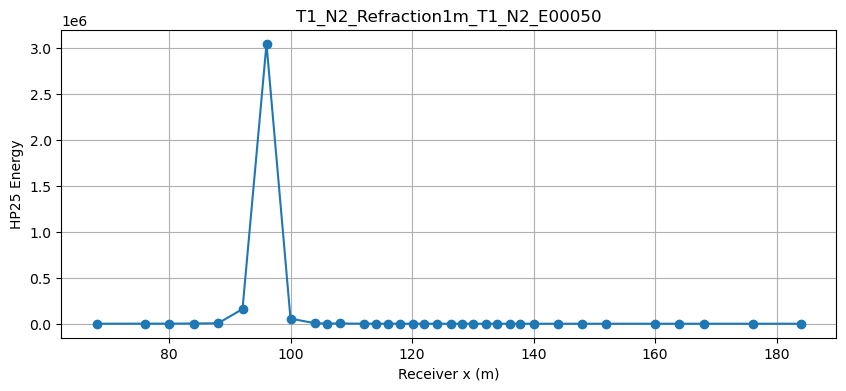

In [32]:
metric = est["metric"].sort_values("receiver_x_m")

plt.figure(figsize=(10,4))
plt.plot(
    metric["receiver_x_m"],
    metric["energy_hp25"],
    "o-"
)
plt.xlabel("Receiver x (m)")
plt.ylabel("HP25 Energy")
plt.title(event_id)
plt.grid(True)
plt.show()

NameError: name 'geode_source_x_m' is not defined

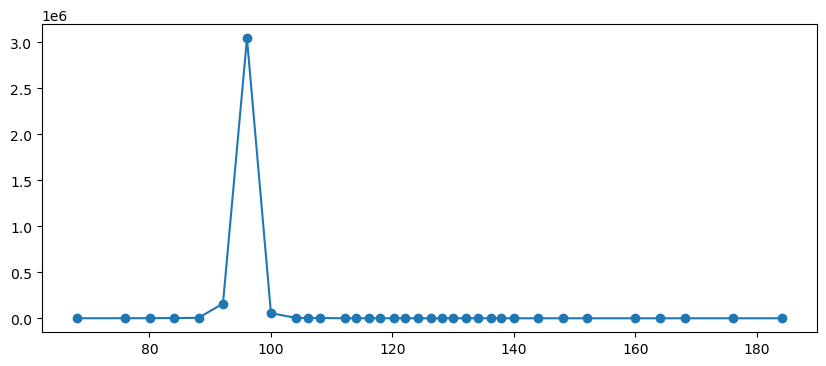

In [33]:
fig, ax = plt.subplots(figsize=(10,4))

ax.plot(
    metric["receiver_x_m"],
    metric["energy_hp25"],
    "o-"
)

ax.axvline(
    geode_source_x_m,
    color="red",
    linestyle="--",
    label=f"metadata source {geode_source_x_m:.1f} m"
)

ax.axvline(
    est["estimated_source_x_m"],
    color="green",
    linestyle="-",
    label=f"estimated {est['estimated_source_x_m']:.1f} m"
)

ax.legend()
ax.grid(True)

plt.show()

## 8. Save candidate matches to SQLite and CSV

This table is not final truth. It is a review queue.


In [ ]:
if len(match_candidates_df):
    # Replace candidates for the selected nodal events only.
    ids = tuple(match_candidates_df['nodal_event_id'].unique())
    if len(ids) == 1:
        conn.execute('DELETE FROM nodal_geode_match_candidates WHERE nodal_event_id = ?', (ids[0],))
    else:
        placeholders = ','.join(['?'] * len(ids))
        conn.execute(f'DELETE FROM nodal_geode_match_candidates WHERE nodal_event_id IN ({placeholders})', ids)
    conn.commit()
    match_candidates_df.to_sql('nodal_geode_match_candidates', conn, if_exists='append', index=False)
    conn.commit()

source_estimates_df.to_csv(OUTPUT_DIR / 'nodal_source_position_estimates_for_review.csv', index=False)
if len(match_candidates_df):
    match_candidates_df.to_csv(OUTPUT_DIR / 'nodal_geode_match_candidates_for_review.csv', index=False)

print('Wrote review files to:', OUTPUT_DIR)


## 9. Interactive visual review

Set `REVIEW_EVENT_ID` to a nodal event ID. The plot shows the nodal Z gather and overlays:

- estimated nodal source position
- candidate Geode source positions

Use this section to decide which candidate, if any, should be accepted.


In [ ]:
# Pick an event to inspect.
if len(match_candidates_df):
    REVIEW_EVENT_ID = match_candidates_df.iloc[0]['nodal_event_id']
else:
    REVIEW_EVENT_ID = needs_match.iloc[0]['event_id'] if len(needs_match) else None

REVIEW_EVENT_ID


In [ ]:
def plot_review_event(event_id, candidates_df=None, tmin=0.0, tmax=0.5):
    st, path = load_nodal_gather(event_id)
    # Z only for clarity.
    stz = st.select(channel='*Z')
    est = estimate_source_x_from_gather(event_id, st, component='Z')
    candidates = pd.DataFrame()
    if candidates_df is not None and len(candidates_df):
        candidates = candidates_df[candidates_df['nodal_event_id'].astype(str) == str(event_id)].copy()

    if HAVE_SEGY_TOOLS:
        fig = plot_wiggle_gather_from_stream(
            stz,
            sort_by='receiver_x',
            fallback_receiver_spacing_m=1.0,
            fallback_first_receiver_x_m=0.0,
            title=f'{event_id} — nodal Z gather with candidate source positions',
            tmin=tmin,
            tmax=tmax,
            scale=0.8,
            clip_percentile=99,
            normalize=True,
        )
        ax = plt.gca()
    else:
        fig, ax = plt.subplots(figsize=(12, 6))
        for tr in stz:
            x = trace_receiver_x(event_id, tr)
            y = np.arange(tr.stats.npts) * tr.stats.delta
            d = tr.data.astype(float)
            d = d / (np.nanmax(np.abs(d)) or 1.0)
            ax.plot(x + d, y, lw=0.5)
        ax.invert_yaxis()
        ax.set_xlabel('Receiver x (m)')
        ax.set_ylabel('Time (s)')
        ax.set_ylim(tmax, tmin)

    if np.isfinite(est['estimated_source_x_m']):
        ax.axvline(est['estimated_source_x_m'], color='red', lw=2, label=f"Nodal estimate {est['estimated_source_x_m']:.1f} m")

    if len(candidates):
        for _, row in candidates.head(5).iterrows():
            gx = pd.to_numeric(pd.Series([row['geode_source_x_m']]), errors='coerce').iloc[0]
            if np.isfinite(gx):
                ax.axvline(gx, color='orange', lw=1, alpha=0.8)
                ax.text(gx, tmin, f"{row['geode_event_id']} score={row['score']:.1f}", rotation=90, va='bottom', fontsize=8)

    ax.legend(loc='upper right')
    plt.show()

    print('Gather:', path)
    print('Source estimate:', {k:v for k,v in est.items() if k != 'metric'})
    if len(candidates):
        display(candidates.head(10))
    return st, est, candidates

if REVIEW_EVENT_ID is not None:
    st_review, est_review, cand_review = plot_review_event(REVIEW_EVENT_ID, match_candidates_df, tmin=0, tmax=0.5)


## 10. Accept/reject reviewed matches

Edit `ACCEPTED_MATCHES` manually after visual inspection. Then run the next cell to write accepted/rejected matches to SQLite.

Format:

```python
ACCEPTED_MATCHES = {
    'NODAL_EVENT_ID': {
        'geode_event_id': 'GEODE_EVENT_ID',
        'accepted': True,
        'notes': 'Looks correct; source position and time agree.'
    }
}
```

Use `accepted=False` to record a deliberate rejection.


In [ ]:
ACCEPTED_MATCHES = {
    # Example:
    # 'NODAL_EVENT_ID_HERE': {
    #     'geode_event_id': 'GEODE_EVENT_ID_HERE',
    #     'accepted': True,
    #     'notes': 'Confirmed by wiggle plot and source position.'
    # },
}


In [ ]:
def write_reviewed_matches(conn, accepted_matches, candidates_df, reviewer='Glenn'):
    rows = []
    now = datetime.now(timezone.utc).isoformat()
    for nodal_id, item in accepted_matches.items():
        geode_id = item.get('geode_event_id')
        accepted = int(bool(item.get('accepted', True)))
        notes = item.get('notes', '')
        cand = candidates_df[
            (candidates_df['nodal_event_id'].astype(str) == str(nodal_id)) &
            (candidates_df['geode_event_id'].astype(str) == str(geode_id))
        ].copy() if len(candidates_df) else pd.DataFrame()
        if len(cand):
            best = cand.sort_values('score', ascending=False).iloc[0]
            rows.append({
                'nodal_event_id': nodal_id,
                'geode_event_id': geode_id,
                'accepted': accepted,
                'review_status': 'accepted' if accepted else 'rejected',
                'review_time_utc': now,
                'reviewer': reviewer,
                'notes': notes,
                'source_x_m': best.get('geode_source_x_m'),
                'source_type': best.get('source_type'),
                'operator': best.get('operator'),
                'plate_type': best.get('plate_type'),
                'n_blows': best.get('n_blows'),
                'geode_file_no': best.get('geode_file_no'),
                'time_residual_s': best.get('time_residual_s'),
                'nodal_estimated_source_x_m': best.get('nodal_estimated_source_x_m'),
                'source_x_residual_m': best.get('source_x_residual_m'),
            })
        else:
            rows.append({
                'nodal_event_id': nodal_id,
                'geode_event_id': geode_id,
                'accepted': accepted,
                'review_status': 'accepted_no_candidate_row' if accepted else 'rejected_no_candidate_row',
                'review_time_utc': now,
                'reviewer': reviewer,
                'notes': notes,
            })
    if not rows:
        print('No reviewed matches to write.')
        return pd.DataFrame()
    df = pd.DataFrame(rows)
    for nodal_id in df['nodal_event_id'].unique():
        conn.execute('DELETE FROM nodal_geode_matches_reviewed WHERE nodal_event_id = ?', (nodal_id,))
    conn.commit()
    df.to_sql('nodal_geode_matches_reviewed', conn, if_exists='append', index=False)
    conn.commit()
    return df

reviewed_df = write_reviewed_matches(conn, ACCEPTED_MATCHES, match_candidates_df)
display(reviewed_df)


## 11. Optional: apply accepted metadata back to nodal `shot_events`

Only run this after you are comfortable with reviewed matches. This updates nodal rows in `shot_events` with accepted source metadata.


In [ ]:
APPLY_ACCEPTED_MATCHES_TO_SHOT_EVENTS = False

if APPLY_ACCEPTED_MATCHES_TO_SHOT_EVENTS:
    reviewed = pd.read_sql("SELECT * FROM nodal_geode_matches_reviewed WHERE accepted = 1", conn)
    print('Accepted matches:', len(reviewed))
    for _, r in reviewed.iterrows():
        conn.execute('''
            UPDATE shot_events
            SET matched_metadata_event_id = ?,
                source_x_m = ?,
                source_type = ?,
                operator = ?,
                plate_type = ?,
                n_blows = ?,
                file_no = ?,
                metadata_match_status = ?,
                metadata_time_residual_s = ?
            WHERE event_id = ?
        ''', (
            r.get('geode_event_id'),
            r.get('source_x_m'),
            r.get('source_type'),
            r.get('operator'),
            r.get('plate_type'),
            r.get('n_blows'),
            r.get('geode_file_no'),
            'reviewed_match',
            r.get('time_residual_s'),
            r.get('nodal_event_id'),
        ))
    conn.commit()
    print('Updated shot_events with accepted reviewed matches.')
else:
    print('Not applying reviewed matches to shot_events yet.')


## 12. Summary exports

In [ ]:
summary = {
    'n_nodal_events': len(nodal_events),
    'n_geode_events': len(geode_events),
    'n_review_subset': len(needs_match),
    'n_source_estimates': len(source_estimates_df),
    'n_match_candidates': len(match_candidates_df),
}
print(json.dumps(summary, indent=2))

with open(OUTPUT_DIR / 'match_review_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
